In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

In [2]:
filename = 'paysim_transactions.csv.gz' 

In [3]:
# load the file into a DataFrame 
df = pd.read_csv(filename)

In [4]:
# sort df by step 
df = df.sort_values(by='step', kind = 'stable')

# groupb by nameOrig and apply cumcount()
df['prior_txn_count'] = df.groupby(by='nameOrig').cumcount()

In [5]:
filtered_df = df[df['action'].isin(['TRANSFER', 'CASH_OUT'])]

filtered_df['day'] = filtered_df['step'] // 24 

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_82292/1268824503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['day'] = filtered_df['step'] // 24


In [6]:
filtered_df.groupby(by=['action', 'isFraud'])['prior_txn_count'].describe()

count         mean           std  min   25%    50%  \
action   isFraud                                                          
CASH_OUT 0        799683.0  2758.714769  13213.508090  0.0  65.0  134.0   
         1           684.0     0.000000      0.000000  0.0   0.0    0.0   
TRANSFER 0        199622.0  2480.832378  12537.928112  0.0  59.0  122.0   
         1           684.0   113.811404    136.926462  0.0  19.0   64.5   

                    75%       max  
action   isFraud                   
CASH_OUT 0        261.0  106486.0  
         1          0.0       0.0  
TRANSFER 0        240.0  106458.0  
         1        164.0     762.0

In [7]:
((filtered_df['action'] == 'CASH_OUT') & (filtered_df['prior_txn_count'] == 0)).sum()
# thus, zero history doensn't mean that it is a mule; it can very much be a legit customer since there are 919 customers that CASH_OUT-ing

np.int64(919)

## Feature 1: CASH_OUT 

In [8]:
# CASH_OUT
cash_out_df = filtered_df[filtered_df['action'] == 'CASH_OUT']

# recall = flagged & fraud / total fraud 
cash_out_recall = ((cash_out_df['isFraud'] == 1) & (cash_out_df['prior_txn_count'] == 0)).sum() / (cash_out_df['isFraud'] == 1).sum()

# precision = flagged & fraud / total flagged 
cash_out_prec = ((cash_out_df['isFraud'] == 1) & (cash_out_df['prior_txn_count'] == 0)).sum() /  (cash_out_df['prior_txn_count'] == 0).sum()

In [9]:
print (cash_out_recall, cash_out_prec)

1.0 0.7442872687704026


In PaySim, every mule account is brand new, and its first action is always the cash-out. Real mule accounts are oftend 'warmed up' with small normal transactions first, so this signal would be weaker in practice. 

## Feature 2: Is this amount unusual for this account? 

In [10]:
df = df.copy()

# total amount this sender moved BEFORE this transaction   
df['prior_amount_sum'] = df.groupby(by='nameOrig')['amount'].cumsum() - df['amount']

# sender's average past transaction amount; NaN for account's first transaction 
df['prior_amount_mean'] = df['prior_amount_sum'] / df['prior_txn_count']

# how many times larger this transaction is than the sender's usual amount 
df['amount_ratio'] = df['amount'] / df['prior_amount_mean'] 

In [11]:
df['amount_ratio'].isna().sum(), np.isinf(df['amount_ratio']).sum()

(np.int64(20682), np.int64(0))

In [14]:
filtered_df = df[df['action'].isin(['TRANSFER', 'CASH_OUT'])]

In [18]:
filtered_df.groupby(by=['action','isFraud'])['amount_ratio'].describe()

count       mean        std       min        25%  \
action   isFraud                                                        
CASH_OUT 0        799448.0   1.029852   1.179061  0.000015   0.612394   
         1             0.0        NaN        NaN       NaN        NaN   
TRANSFER 0        199511.0   6.977141   8.198906  0.000031   2.351850   
         1           673.0  32.239635  25.266876  0.134721  19.659753   

                        50%        75%         max  
action   isFraud                                    
CASH_OUT 0         0.953664   1.340137  732.152109  
         1              NaN        NaN         NaN  
TRANSFER 0         4.639911   8.664755  404.251667  
         1        26.606198  35.963302  246.956114

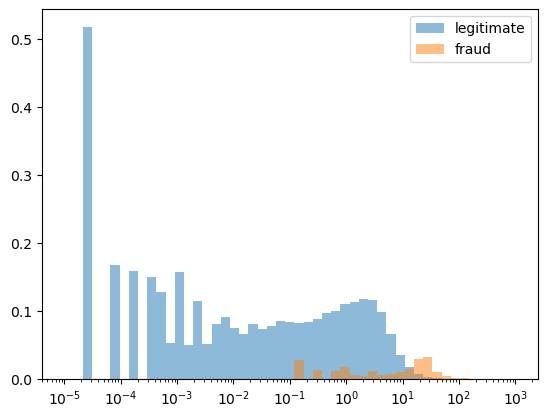

In [31]:
transfers = filtered_df[filtered_df['action'] == 'TRANSFER']

fraud_ratio = transfers[transfers['isFraud'] == 1]['amount_ratio'].dropna()
legit_ratio = transfers[transfers['isFraud'] == 0]['amount_ratio'].dropna()


bins = np.logspace(-5, 3, 50)
fig, ax = plt.subplots()
ax.hist(legit_ratio, bins=bins, density=True, alpha=0.5, label='legitimate')
ax.hist(fraud_ratio, bins=bins, density=True, alpha=0.5, label='fraud')
ax.set_xscale('log')
ax.legend()


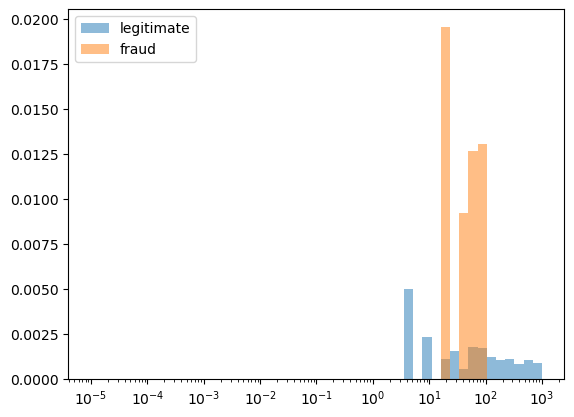

In [32]:
transfers = filtered_df[filtered_df['action'] == 'TRANSFER']

fraud_amount = transfers[transfers['isFraud'] == 1]['amount'].dropna()
legit_amount = transfers[transfers['isFraud'] == 0]['amount'].dropna()


bins = np.logspace(-5, 3, 50)
fig, ax = plt.subplots()
ax.hist(legit_amount, bins=bins, density=True, alpha=0.5, label='legitimate')
ax.hist(fraud_amount, bins=bins, density=True, alpha=0.5, label='fraud')
ax.set_xscale('log')
ax.legend()
